# Exploratory Data Analysis (EDA)

**Author:** Marvin Ernst

**Project:** *production Machine Learning System*

### Objective

Understand the dataset and identify key patterns that influence customer churn.

The results of this analysis will inform feature engineering and model design.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)  
pd.set_option('display.width', None)  
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
df = pd.read_csv('../data/raw/Customer_Churn.csv')

## 1. Dataset Overview

### 1.1 Shape

In [3]:
df.shape

(7043, 21)

### 1.2 Columns + Types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [8]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

## 2. Data Quality

### 2.1 Missing Values

In [9]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 2.2 Duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

### 2.3 Data Issues

In [11]:
df["TotalCharges"].dtype

dtype('O')

We need to transform it to numeric.

In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [13]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [14]:
df[df["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Some columns require type conversion. Missing values are limited and manageable. We see that TotalCharges for those with tenure = 0 are missing, whch makes sense, since these are new customers, so this would be equal to TotalCharges = 0 (those just don't exist but they should).

## 3. Target Analysis

In [15]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [16]:
df['Churn'].value_counts(normalize=True)

Churn
No    0.73
Yes   0.27
Name: proportion, dtype: float64

<Axes: xlabel='Churn', ylabel='count'>

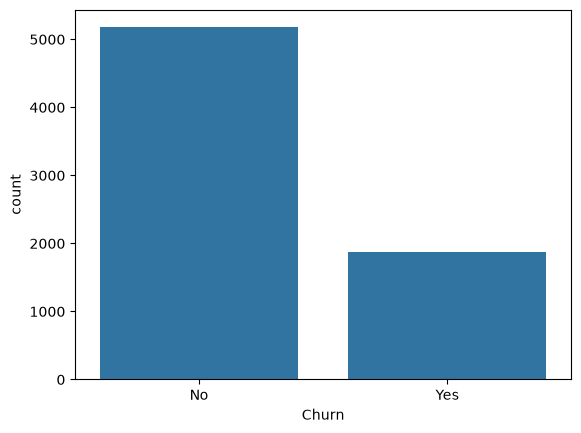

In [17]:
sns.countplot(x="Churn", data=df)

The dataset contains 7043 observations. The target variable is binary and slightly imbalanced with 5174 No and 1869 Yes.

## 4. Feature Analysis

### 4.1 Categorical Features

#### 4.1.1 Contract

In [18]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.57,0.43
One year,0.89,0.11
Two year,0.97,0.03


<Axes: xlabel='Contract', ylabel='count'>

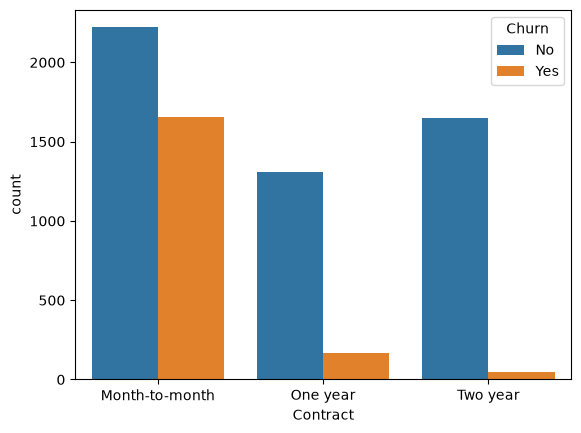

In [19]:
sns.countplot(x="Contract", hue="Churn", data=df)

Customers with month-to-month contracts churn significantly more often.

#### 4.1.2 PhoneService

In [20]:
pd.crosstab(df["PhoneService"], df["Churn"], normalize="index")

Churn,No,Yes
PhoneService,,
No,0.75,0.25
Yes,0.73,0.27


<Axes: xlabel='PhoneService', ylabel='count'>

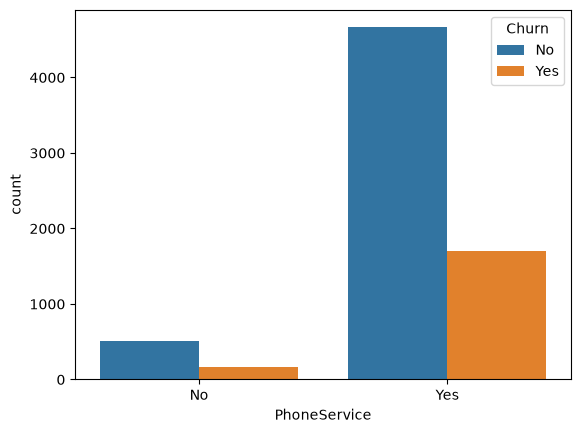

In [21]:
sns.countplot(x="PhoneService", hue="Churn", data=df)

Churn is realtively similar between PhoneService and no PhoneService.

#### 4.1.3 InternetService

In [22]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index")

Churn,No,Yes
InternetService,,
DSL,0.81,0.19
Fiber optic,0.58,0.42
No,0.93,0.07


<Axes: xlabel='InternetService', ylabel='count'>

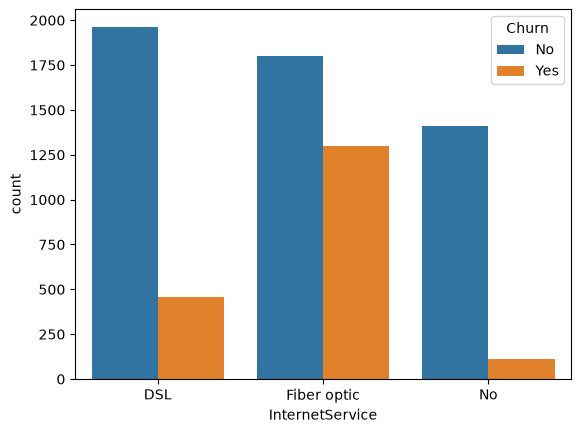

In [23]:
sns.countplot(x="InternetService", hue="Churn", data=df)

Chrun is significantly higher among those with Fiber optic InternetService, than those with no InternetService or DSL.

#### 4.1.4 PaymentMethod

In [24]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index")

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.83,0.17
Credit card (automatic),0.85,0.15
Electronic check,0.55,0.45
Mailed check,0.81,0.19


<Axes: xlabel='PaymentMethod', ylabel='count'>

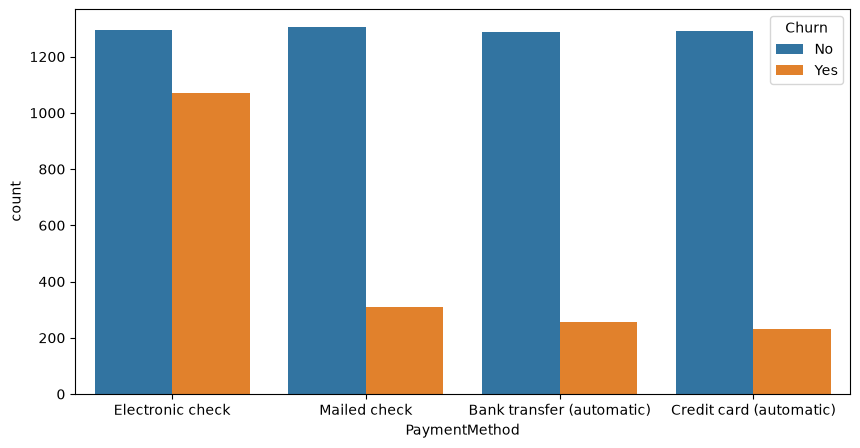

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)

Those with Electronic check have a significantly higher churn rate than those with other payment methods.

### 4.2 Numerical Features

#### 4.2.1 Tenure

<Axes: xlabel='Churn', ylabel='tenure'>

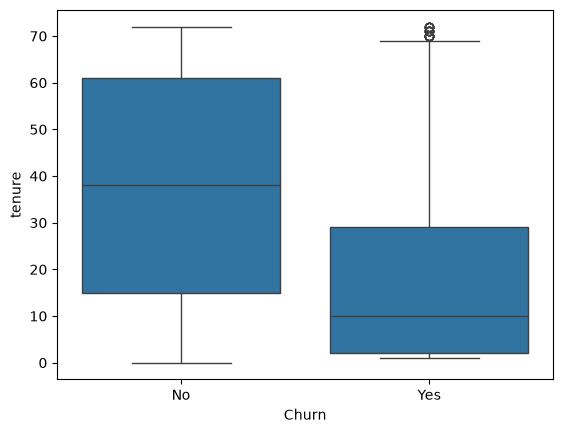

In [26]:
sns.boxplot(x="Churn", y="tenure", data=df)

Customers with shorter tenure are more likely to churn.

#### 4.2.1 MonthlyCharges

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

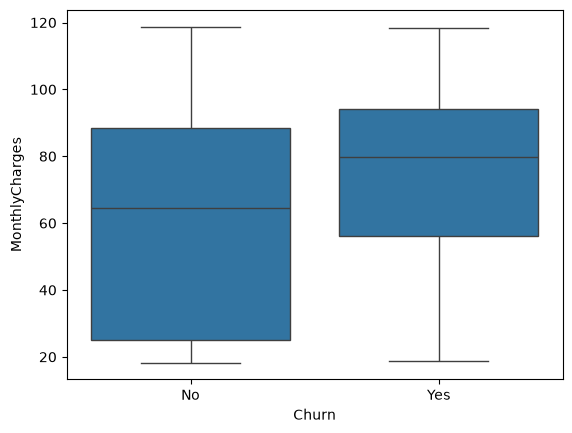

In [27]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

Higher monthly charges may correlate with increased churn risk.

## 5. Correlation

In [28]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [29]:
df = df.drop(columns=["customerID"])

In [30]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [31]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   gender_Male                            7043 non-null   bool   
 6   Partner_Yes                            7043 non-null   bool   
 7   Dependents_Yes                         7043 non-null   bool   
 8   PhoneService_Yes                       7043 non-null   bool   
 9   MultipleLines_No phone service         7043 non-null   bool   
 10  MultipleLines_Yes                      7043 non-null   bool   
 11  Inte

<Axes: >

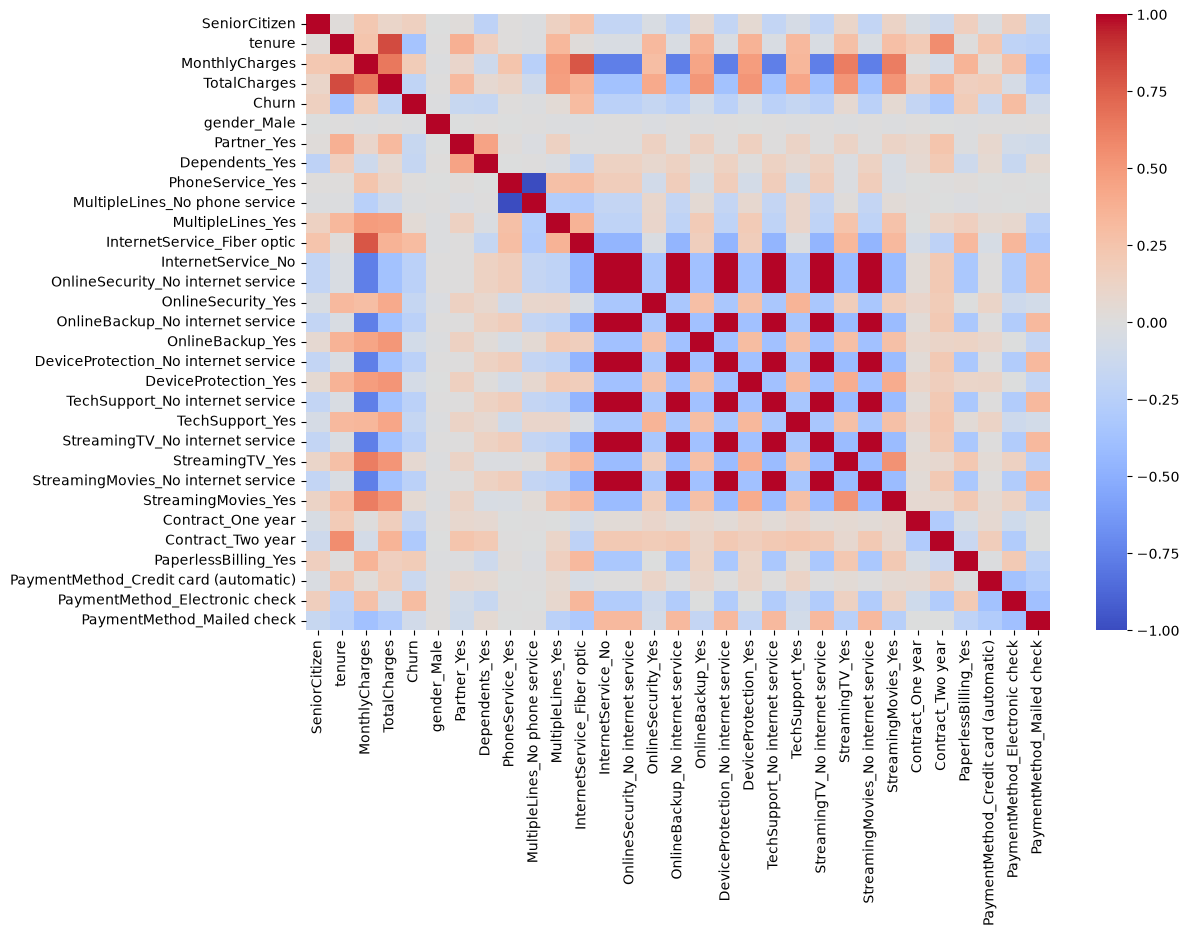

In [32]:
corr = df_encoded.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)

In [33]:
corr_target = corr["Churn"].sort_values(ascending=False)
corr_target.head(10)

Churn                            1.00
InternetService_Fiber optic      0.31
PaymentMethod_Electronic check   0.30
MonthlyCharges                   0.19
PaperlessBilling_Yes             0.19
SeniorCitizen                    0.15
StreamingTV_Yes                  0.06
StreamingMovies_Yes              0.06
MultipleLines_Yes                0.04
PhoneService_Yes                 0.01
Name: Churn, dtype: float64

## 6. Key Findings

- Customers with short tenure have higher churn rates
- Month-to-month contracts show significantly higher churn
- Customers with electronic checks have higher churn rates
- Fiber optic Internet Service has a significantly higher churn rate
- Higher monthly charges are associated with churn
- Dataset is moderately imbalanced

## 7. Implications for Modeling

- Use classification models (binary target)
- Handle categorical variables via encoding (e.g. one-hot)
- Consider class imbalance (e.g. class weights or appropriate metrics)
- Include tenure, contract type, and charges as key features